# Sequential Group Composition with RNNs

This notebook reproduces the RNN experiments. For $G = C_n \times C_n$, the trained network exhibits sequential-composition structure: $W_{\mathrm{out}}$ specializes to irrep-aligned modes, while $W_{\mathrm{mix}}$ becomes approximately block diagonal in the same Fourier decomposition.

## Imports

In [1]:
# Core
import os
import random
import numpy as np
import torch
import torch.nn as nn

# Torch utilities
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Vision
import torchvision
from torchvision import transforms

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Patch
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

# Misc
from tqdm import tqdm
from typing import Optional

## Reproducibility


In [2]:
GLOBAL_SEED = 5

def set_reproducibility(seed: int = GLOBAL_SEED) -> torch.Generator:
    """
    Reset every source of randomness used in this notebook.

    Re-running the notebook from top to bottom with the same seed should produce
    the same dataset, initialization, minibatch order, training trajectory, and plots
    on the same hardware/software stack.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Disable nondeterministic cuDNN autotuning.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    # Ask PyTorch to use deterministic kernels whenever possible.
    # warn_only=True avoids hard failures if a deterministic version of a
    # backend kernel is unavailable.
    torch.use_deterministic_algorithms(True, warn_only=True)

    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator

rng = set_reproducibility(GLOBAL_SEED)


## RNN Architecture

In [3]:
class QuadraticRNN(nn.Module):
    """
    Quadratic RNN used for sequential group composition.

    Given a sequence x_seq = (x_{g_1}, ..., x_{g_k}), this network computes

        h^{(2)} = sigma(W_in x_{g_1} + W_drive x_{g_2})
        h^{(i)} = sigma(W_mix h^{(i-1)} + W_drive x_{g_i}),  i = 3, ..., k
        yhat     = W_out h^{(k)}

    where sigma(z) = z^2 is applied elementwise.

    Shapes:
        x_seq: (batch, k, p)
        W_in: (d, p)
        W_drive: (d, p)
        W_mix: (d, d)
        W_out: (p, d)
        output: (batch, p)
    """

    def __init__(
        self,
        p: int,
        d: int,
        init_scale: float = 1e-2,
    ) -> None:
        """
        Args:
            p: size of the input/output representation, equal to |G|
            d: hidden dimension H
            init_scale: scale of weights at initialization
        """
        super().__init__()
        self.p = p
        self.d = d
        self.init_scale = init_scale

        self.W_in = nn.Parameter(init_scale * torch.randn(d, p) / np.sqrt(p))
        self.W_drive = nn.Parameter(init_scale * torch.randn(d, p) / np.sqrt(p))
        self.W_mix = nn.Parameter(init_scale * torch.randn(d, d) / np.sqrt(d))
        self.W_out = nn.Parameter(init_scale * torch.randn(p, d) / np.sqrt(d))

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x_seq: tensor of shape (batch, k, p), representing
                   (x_{g_1}, ..., x_{g_k})

        Returns:
            y: tensor of shape (batch, p)
        """
        batch, k, p = x_seq.shape

        assert p == self.p, f"Expected input dimension {self.p}, got {p}"
        assert k >= 2, "QuadraticRNN requires sequences of length at least 2"

        # h^{(2)} = sigma(W_in x_{g_1} + W_drive x_{g_2})
        x1 = x_seq[:, 0, :]  # (batch, p)
        x2 = x_seq[:, 1, :]  # (batch, p)

        pre = (x1 @ self.W_in.T) + (x2 @ self.W_drive.T)  # (batch, d)
        h = pre**2

        # h^{(i)} = sigma(W_mix h^{(i-1)} + W_drive x_{g_i})
        # for i = 3, ..., k
        for t in range(2, k):
            xt = x_seq[:, t, :]  # (batch, p)
            pre = (h @ self.W_mix.T) + (xt @ self.W_drive.T)
            h = pre**2

        # yhat = W_out h^{(k)}
        y = h @ self.W_out.T  # (batch, p)
        return y

## Optimization

In [4]:
def test_accuracy_seq(model: nn.Module, dataloader: DataLoader) -> float:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, Y_batch in dataloader:
            outputs = model(X_batch)  # (B, p)
            pred = outputs.argmax(dim=1)
            true = Y_batch.argmax(dim=1)
            correct += (pred == true).sum().item()
            total += Y_batch.size(0)
    return 100.0 * correct / total


def train_seq(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    epochs: int = 2000,
    verbose_interval: int = 100,
    grad_clip: Optional[float] = None,
) -> tuple[list[float], list[float], list[dict[str, torch.Tensor]]]:
    loss_history, acc_history, param_history = [], [], []

    # --- BEFORE TRAINING (epoch 0) ---
    model.eval()
    with torch.no_grad():
        # avg loss over data
        total = 0.0
        for Xb, Yb in dataloader:
            out = model(Xb)
            total += criterion(out, Yb).item()
        loss0 = total / len(dataloader)
        acc0 = test_accuracy_seq(model, dataloader)
        snap0 = {n: p.detach().cpu().clone() for n, p in model.named_parameters()}

    loss_history.append(loss0)
    acc_history.append(acc0)
    param_history.append(snap0)

    # --- TRAINING LOOP (epochs 1..epochs) ---
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for X_batch, Y_batch in dataloader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running += loss.item()

        avg_loss = running / len(dataloader)
        loss_history.append(avg_loss)

        model.eval()
        acc = test_accuracy_seq(model, dataloader)
        acc_history.append(acc)

        with torch.no_grad():
            snap = {n: p.detach().cpu().clone() for n, p in model.named_parameters()}
        param_history.append(snap)

        if epoch % verbose_interval == 0:
            print(f"[RNN] Epoch {epoch}/{epochs} | loss {avg_loss:.6f} | acc {acc:.2f}%")

    return loss_history, acc_history, param_history

## Plotting functions

In [5]:
def style_axes(ax, numyticks=5, numxticks=5, labelsize=24):
    # Y-axis ticks
    ax.tick_params(
        axis="y",
        which="both",
        bottom=True,
        top=False,
        labelbottom=True,
        left=True,
        right=False,
        labelleft=True,
        direction="out",
        length=7,
        width=1.5,
        pad=8,
        labelsize=labelsize,
    )
    ax.yaxis.set_major_locator(MaxNLocator(nbins=numyticks))

    # X-axis ticks
    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        top=False,
        labelbottom=True,
        left=True,
        right=False,
        labelleft=True,
        direction="out",
        length=7,
        width=1.5,
        pad=8,
        labelsize=labelsize,
    )
    ax.xaxis.set_major_locator(MaxNLocator(nbins=numxticks))

    # # Scientific notation formatting
    # if ax.get_yscale() == "linear":
    #     ax.ticklabel_format(style="sci", axis="y", scilimits=(-2, 2))
    # if ax.get_xscale() == "linear":
    #     ax.ticklabel_format(style="sci", axis="x", scilimits=(-2, 2))

    ax.xaxis.offsetText.set_fontsize(20)
    ax.grid()

    # Customize spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(3)

In [6]:
## 2D Plotting Functions

def get_power_2d(points_2d):
    """
    Compute 2D power spectrum using rfft2 (for real-valued inputs).

    Args:
        points_2d: (p1, p2) array

    Returns:
        power: (p1//2+1, p2) array of power values
        freqs_x: frequency indices along x
        freqs_y: frequency indices along y
    """
    p1, p2 = points_2d.shape

    # Perform 2D FFT (rfft2 for real input)
    ft = np.fft.fft2(points_2d)  # shape: (p1//2+1, p2) for rfft, (p1, p2) for fft
    power = np.abs(ft) ** 2 / (p1 * p2)

    freqs_x = np.fft.fftfreq(p1, 1.0) * p1  # or np.arange(p1) for index-based
    freqs_y = np.fft.fftfreq(p2, 1.0) * p2  # or np.arange(p2) for index-based

    return power, freqs_x, freqs_y


def plot_2d_signal(
    ax,
    signal_2d,
    title="",
    cmap="RdBu_r",
    colorbar=True,
):
    """Plot a 2D signal as a heatmap."""
    im = ax.imshow(signal_2d, cmap=cmap, aspect="equal", interpolation="nearest")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("y", fontsize=12)
    ax.set_ylabel("x", fontsize=12)
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


def plot_2d_power_spectrum(
    ax,
    power_2d,
    fx=None,
    fy=None,
    title="Power Spectrum",
    cmap="viridis",
    log_scale=True,
    shift=True,
):
    """Plot 2D power spectrum with proper frequency axes."""
    if log_scale:
        power_plot = np.log10(power_2d + 1e-12)
        title = f"{title} (log₁₀)"
    else:
        power_plot = power_2d

    # Optionally shift to center zero frequency
    if shift:
        power_plot = np.fft.fftshift(power_plot)
        if fx is not None and fy is not None:
            fx = np.fft.fftshift(fx)
            fy = np.fft.fftshift(fy)

    # Set up extent for proper frequency axis labeling
    if fx is not None and fy is not None:
        extent = [fy.min(), fy.max(), fx.min(), fx.max()]
    else:
        extent = None

    im = ax.imshow(
        power_plot,
        cmap=cmap,
        aspect="equal",
        interpolation="nearest",
        origin="lower",
        extent=extent,
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("k_y (frequency)", fontsize=12)
    ax.set_ylabel("k_x (frequency)", fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


def get_power_2d_adele(points, no_freq=False):
    M, N = points.shape
    
    # Perform 2D rFFT
    ft = np.fft.rfft2(points)
    
    # Power spectrum normalized by total number of samples
    power = np.abs(ft)**2 / (M * N)

    # Construct weighting to handle real conjugate symmetry
    weight =  2 * np.ones((M, N // 2 + 1))
    weight[0,0] = 1 # handles DC component
    weight[(M//2 + 1):, 0] = 0 # handles DC frequency in second axis
    if M % 2 == 0:
        weight[M//2, 0] = 1
    if N % 2 == 0:
        weight[(M//2 + 1):, N//2] = 0
        weight[0, N//2] = 1
    if (M % 2 == 0) and (N % 2 == 0):
        weight[M//2, N//2] = 1

    # Reweight power to account for redundancies
    power = weight * power


    # Check Parseval’s theorem
    total_power = np.sum(power)
    norm_squared = np.linalg.norm(points)**2
    if not np.isclose(total_power, norm_squared, rtol=1e-6):
        print(f"Warning: Total power {total_power:.3f} does not match norm squared {norm_squared:.3f}")


    if no_freq:
        return power

    # Frequency bins
    freqs_u = np.fft.fftfreq(M)          # full symmetric frequencies (rows)
    freqs_v = np.fft.rfftfreq(N)         # only non-negative frequencies (columns)

    return freqs_u, freqs_v, power


def topk_template_freqs(template_2d: np.ndarray, K: int, min_power: float = 1e-20):
    """
    Return top-K (kx, ky) rFFT2 bins by power from get_power_2d_adele(template_2d).
    """
    freqs_u, freqs_v, power = get_power_2d_adele(template_2d)  # power shape: (p1, p2//2 + 1)
    shp = power.shape
    flat = power.ravel()
    mask = flat > min_power
    if not np.any(mask):
        return []
    top_idx = np.flatnonzero(mask)[np.argsort(flat[mask])[::-1]][:K]
    kx, ky = np.unravel_index(top_idx, shp)
    return list(zip(kx.tolist(), ky.tolist()))

## 2D Dataset

In [7]:
def gaussian_mixture_template(p1=20, p2=20, n_blobs=8, frac_broad=0.7,
                              sigma_broad=(3.5, 6.0), sigma_narrow=(1.0, 2.0),
                              amp_broad=1.0, amp_narrow=0.5,
                              seed=None, normalize=True):
    """
    Build a (p1 x p2) template as a periodic mixture of Gaussians.
    Broad Gaussians (low-frequency) get higher weight; a few narrow ones add detail.
    """
    rng = np.random.default_rng(seed)
    H, W = p1, p2
    Y, X = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")

    k_broad = int(round(n_blobs * frac_broad))
    k_narrow = n_blobs - k_broad

    def add_blobs(k, sigma_range, amp):
        out = np.zeros((H, W), dtype=float)
        for _ in range(k):
            cy, cx = rng.uniform(0, H), rng.uniform(0, W)
            sigma = rng.uniform(*sigma_range)
            dy = np.minimum(np.abs(Y - cy), H - np.abs(Y - cy))  # periodic (torus) distance
            dx = np.minimum(np.abs(X - cx), W - np.abs(X - cx))
            out += amp * np.exp(-(dx**2 + dy**2) / (2.0 * sigma**2))
        return out

    template = (
        add_blobs(k_broad, sigma_broad, amp_broad) +   # broad, low-freq power
        add_blobs(k_narrow, sigma_narrow, amp_narrow)  # a bit of high-freq detail
    )

    if normalize:
        template -= template.mean()
        s = template.std()
        if s > 1e-12:
            template /= s
    return template.astype(np.float32)

import numpy as np

def generate_template_unique_freqs(p1, p2, n_freqs, amp_max=100, amp_min=10, seed=None):
    """
    Real (p1 x p2) template from n_freqs Fourier modes where:
      - No two selected bins are conjugates of each other.
      - Self-conjugate singletons are excluded.
      - Frequencies are chosen (low→high) by radial order from the rfft-style half-plane.

    Conjugate symmetry: F[ky,kx] = conj( F[-ky mod p1, -kx mod p2] ).
    On the rfft half-plane kx ∈ [0, p2//2]:
      - If 0 < kx < p2//2, the conjugate sits at kx' = p2 - kx (outside the half-plane) → safe.
      - If kx in {0, p2//2 (when even)}, the conjugate keeps the same kx and flips ky → avoid picking both ky and -ky.
      - Self-conjugate happens only if kx in {0, p2//2 (when even)} AND ky in {0, p1//2 (when even)} → exclude.
    """
    rng = np.random.default_rng(seed)
    spectrum = np.zeros((p1, p2), dtype=np.complex128)

    # Helpers
    def ky_signed(ky):  # map ky ∈ [0..p1-1] to signed range
        return ky if ky <= p1 // 2 else ky - p1

    def is_self_conj(ky, kx):
        on_self_kx = (kx == 0) or (p2 % 2 == 0 and kx == p2 // 2)
        if not on_self_kx:
            return False
        s = ky_signed(ky)
        return (s == 0) or (p1 % 2 == 0 and abs(s) == p1 // 2)

    # Build candidate list on rfft half-plane, skip DC and self-conjugate singletons
    cand = []
    for ky in range(p1):
        s = ky_signed(ky)
        for kx in range(p2 // 2 + 1):
            if ky == 0 and kx == 0:
                continue  # DC
            if is_self_conj(ky, kx):
                continue  # exclude singletons
            r2 = (s ** 2) + (kx ** 2)
            cand.append((r2, ky, kx))
    cand.sort(key=lambda t: (t[0], abs(ky_signed(t[1])), t[2]))

    # Select without conjugate collisions
    chosen = []
    seen_axis_pairs = set()  # for kx in {0, mid}, prevent picking both ky and -ky

    mid_kx = p2 // 2 if (p2 % 2 == 0) else None
    for _, ky, kx in cand:
        if len(chosen) >= n_freqs:
            break
        if (kx == 0) or (mid_kx is not None and kx == mid_kx):
            s = ky_signed(ky)
            key = (kx, min(s, -s))  # canonicalize ±ky
            if key in seen_axis_pairs:
                continue
            seen_axis_pairs.add(key)
            chosen.append((ky, kx))
        else:
            # 0 < kx < mid_kx (or no mid): conjugate lives outside half-plane → always safe
            chosen.append((ky, kx))

    if len(chosen) < n_freqs:
        raise ValueError(f"Could only find {len(chosen)} unique non-conjugate bins; "
                         f"requested {n_freqs}. Increase grid size or reduce n_freqs.")

    # Amplitudes + random phases, then place each bin + its conjugate
    amps = np.sqrt(np.linspace(amp_max, amp_min, n_freqs, dtype=float))
    phases = rng.uniform(0.0, 2*np.pi, size=n_freqs)

    for (ky, kx), a, phi in zip(chosen, amps, phases):
        kyc, kxc = (-ky) % p1, (-kx) % p2
        v = a * np.exp(1j * phi)
        spectrum[ky, kx] += v
        spectrum[kyc, kxc] += np.conj(v)

    template = np.fft.ifft2(spectrum).real
    template -= template.mean()
    s = template.std()
    if s > 1e-12:
        template /= s
    return template.astype(np.float32)


def generate_fixed_template_2d(p1: int, p2: int) -> np.ndarray:
    """
    Generate 2D template array from Fourier spectrum.
    
    Args:
        p1: height dimension
        p2: width dimension
    
    Returns:
        template: (p1, p2) real-valued array
    """
    # Generate template array from 2D Fourier spectrum
    spectrum = np.zeros((p1, p2), dtype=complex)
    
    assert p1 > 5 and p2 > 5, "p1 and p2 must be greater than 5"
    
    # Set 2D frequency components with specific amplitudes
    # Format: spectrum[kx, ky] where kx is "vertical freq", ky is "horizontal freq"
    
    # Axis-aligned frequencies
    spectrum[1, 0] = 10.0      # vertical frequency 1
    spectrum[-1, 0] = 10.0     # conjugate
    # spectrum[0, 1] = 10.0      # horizontal frequency 1  
    # spectrum[0, -1] = 10.0     # conjugate
    
    # Higher frequency components
    # spectrum[3, 0] = 7.5
    # spectrum[-3, 0] = 7.5
    spectrum[0, 3] = 7.5
    spectrum[0, -3] = 7.5

    # Diagonal/mixed frequencies
    spectrum[2, 1] = 5.0
    spectrum[-2, -1] = 5.0    # conjugate
    # spectrum[1, 2] = 5.0
    # spectrum[-1, -2] = 5.0    # conjugate
    
    # Generate signal from spectrum
    template = np.fft.ifft2(spectrum).real
    
    return template

def mnist_template_2d(p1: int, p2: int, label: int, root: str = "data"):
    """
    Return a (p1, p2) template from a random MNIST image of the given class label (0–9).
    Values are float32 in [0, 1].
    """
    if not (0 <= int(label) <= 9):
        raise ValueError("label must be an integer in [0, 9].")

    ds = torchvision.datasets.MNIST(root=root, train=True, download=True, transform=transforms.ToTensor())
    cls_idxs = (ds.targets == int(label)).nonzero(as_tuple=True)[0]
    if cls_idxs.numel() == 0:
        raise ValueError(f"No samples for label {label}.")

    idx = cls_idxs[torch.randint(len(cls_idxs), (1,)).item()].item()
    img, _ = ds[idx]  # img: (1, 28, 28) in [0,1]
    img = nn.functional.interpolate(img.unsqueeze(0), size=(p1, p2), mode="bilinear", align_corners=False)[0, 0]
    return img.numpy().astype(np.float32)  # (p1, p2)


# Spherically Symmetric Templates

def _fft_indices(n):
    """
    Return integer-like frequency indices aligned with numpy's FFT layout.
    Example: n=8 -> [0,1,2,3,4,-3,-2,-1]
    """
    k = np.fft.fftfreq(n) * n
    return k.astype(int)

def generate_hexagon_tie_template_2d(p1: int, p2: int, k0: float = 6.0, amp: float = 1.0):
    """
    Real template whose 2D Fourier spectrum has equal maxima at six directions
    (0°, 60°, 120°, 180°, 240°, 300°) with radius ~ k0 (in FFT index units).
    
    Args:
        p1, p2: spatial dims (height, width). Require > 5 recommended.
        k0: desired radius (index units). Not necessarily integer; we round.
        amp: amplitude per spike (before conjugate pairing)
        
    Returns:
        template: (p1, p2) real-valued array
    """
    assert p1 > 5 and p2 > 5, "p1 and p2 must be > 5"
    spec = np.zeros((p1, p2), dtype=np.complex128)

    # Six target angles for a hexagon
    thetas = np.arange(6) * (np.pi / 3.0)

    # FFT index grids
    Kx = _fft_indices(p1)
    Ky = _fft_indices(p2)

    # Map from (kx,ky) in index space to array indices (wrapped)
    def put(kx, ky, val):
        spec[int(kx) % p1, int(ky) % p2] += val

    used = set()
    for th in thetas:
        # Target continuous coordinates at radius k0
        kx_f = k0 * np.cos(th)
        ky_f = k0 * np.sin(th)
        # Round to nearest integer grid point
        kx = int(np.round(kx_f))
        ky = int(np.round(ky_f))
        # Avoid (0,0) and duplicates
        if (kx, ky) == (0, 0):
            # nudge radius by 1 if rounding hit DC
            if abs(np.cos(th)) > abs(np.sin(th)):
                kx = 1 if kx >= 0 else -1
            else:
                ky = 1 if ky >= 0 else -1
        if (kx, ky) in used:
            continue
        used.add((kx, ky))
        used.add((-kx, -ky))

        # Place equal-amplitude spikes with Hermitian symmetry
        put(kx, ky, amp)                     # +k
        put(-kx, -ky, np.conjugate(amp))     # -k (conjugate)

    # Remove DC (optional) to avoid mean offset
    spec[0, 0] = 0.0

    # Real template
    x = np.fft.ifft2(spec).real
    return x
    
def generate_ring_isotropic_template_2d(p1: int, p2: int, r0: float = 6.0, sigma: float = 0.5, total_power: float = 1.0):
    """
    Real template with a narrow, isotropic ring in the 2D spectrum: |X(k)| ≈ exp(- (||k||-r0)^2 / (2 sigma^2)).
    This produces a spherical (circular) symmetry -> orientation tie across the ring.

    Args:
        p1, p2: spatial dims
        r0: target radius (index units)
        sigma: radial width of the ring
        total_power: scales overall energy (roughly)

    Returns:
        template: (p1, p2) real-valued array
    """
    assert p1 > 5 and p2 > 5, "p1 and p2 must be > 5"

    # Build index grids in FFT layout
    kx = _fft_indices(p1)[:, None]  # (p1,1)
    ky = _fft_indices(p2)[None, :]  # (1,p2)
    R = np.sqrt(kx**2 + ky**2)

    # Radial Gaussian ring (real, even -> already Hermitian when phases are 0)
    mag = np.exp(-0.5 * ((R - r0) / max(sigma, 1e-6))**2)

    # Optional: zero DC
    mag[0, 0] = 0.0

    # Normalize to desired total power (approximate; ifft2 has 1/(p1*p2) factor)
    power = np.sum(mag**2)
    if power > 0:
        mag *= np.sqrt(total_power / power)

    # Real, symmetric spectrum (phase = 0 everywhere)
    spec = mag.astype(np.complex128)

    x = np.fft.ifft2(spec).real
    return x

def generate_gaussian_template_2d(
    p1: int,
    p2: int,
    center: tuple[float, float] = None,
    sigma: float = 2.0,
    k_freqs: int = None,
) -> np.ndarray:
    """
    Generate 2D template with a single Gaussian, optionally band-limited to top-k frequencies.
    Args:
        p1: height dimension
        p2: width dimension
        center: (cx, cy) center position, defaults to center of grid
        sigma: standard deviation of Gaussian
        k_freqs: if not None, keep only the top k frequencies by power (band-limit)
    Returns:
        template: (p1, p2) real-valued array
    """
    if center is None:
        center = (p1 / 2, p2 / 2)
    cx, cy = center
    # Create coordinate grids
    x = np.arange(p1)
    y = np.arange(p2)
    X, Y = np.meshgrid(x, y, indexing="ij")
    # Compute Gaussian
    template = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma**2))
    # If k_freqs specified, band-limit to top-k frequencies
    if k_freqs is not None:
        # Take DFT
        spectrum = np.fft.fft2(template)
        # Compute power for each frequency
        power = np.abs(spectrum) ** 2
        power_flat = power.flatten()
        # Get indices of all frequencies
        kx_indices = np.arange(p1)
        ky_indices = np.arange(p2)
        KX, KY = np.meshgrid(kx_indices, ky_indices, indexing="ij")
        all_indices = list(zip(KX.flatten(), KY.flatten()))
        # Sort by power and select top-k
        sorted_idx = np.argsort(-power_flat)
        top_k_idx = sorted_idx[:k_freqs]
        top_k_freqs = set([all_indices[i] for i in top_k_idx])
        # Create mask: 1 for top-k frequencies, 0 for others
        mask = np.zeros((p1, p2), dtype=complex)
        for kx, ky in top_k_freqs:
            mask[kx, ky] = 1.0
        # Apply mask and take IDFT
        spectrum_masked = spectrum * mask
        template = np.fft.ifft2(spectrum_masked).real
    return template


def ModularAdditionSequenceDataset2D(
    p1: int,
    p2: int,
    template: np.ndarray,
    k: int,
    mode: str = "sampled",
    num_samples: int = 65536,
):
    """
    Generate 2D modular addition dataset.

    Args:
        p1: height (rows) dimension
        p2: width  (cols) dimension
        template: (p1, p2) template array
        k: sequence length
        mode: "sampled" or "exhaustive"
        num_samples: number of samples for "sampled" mode

    Returns:
        X:           (N, k, p1*p2) where token t is template rolled by (ax_t, ay_t), then flattened
        Y:           (N, p1*p2) template rolled by (sum_t ax_t mod p1, sum_t ay_t mod p2), flattened
        sequence_xy: (N, k, 2) integer group elements (ax_t, ay_t) per token (NOT cumulative)

    Notes:
        - axis 0 (rows) is shifted by ax; axis 1 (cols) by ay.
        - To get cumulative positions after each token, use `sequence_to_paths_xy(sequence_xy, p1, p2)`.
    """
    assert template.shape == (p1, p2), f"template must be ({p1}, {p2}), got {template.shape}"
    p_flat = p1 * p2

    if mode == "exhaustive":
        total = (p1 * p2) ** k
        if total > 1_000_000:
            raise ValueError(f"(p1*p2)**k = {total} is huge; use mode='sampled' instead.")
        N = total
        sequence_xy = np.zeros((N, k, 2), dtype=np.int64)
        for idx in range(N):
            for t in range(k):
                flat_idx = (idx // (p_flat ** t)) % p_flat
                ax = flat_idx // p2  # rows
                ay = flat_idx %  p2  # cols
                sequence_xy[idx, t, 0] = ax
                sequence_xy[idx, t, 1] = ay
    else:
        N = int(num_samples)
        sequence_xy = np.empty((N, k, 2), dtype=np.int64)
        sequence_xy[:, :, 0] = np.random.randint(0, p1, size=(N, k))  # ax (rows)
        sequence_xy[:, :, 1] = np.random.randint(0, p2, size=(N, k))  # ay (cols)

    X = np.zeros((N, k, p_flat), dtype=np.float32)
    Y = np.zeros((N, p_flat), dtype=np.float32)

    for i in range(N):
        sx, sy = 0, 0  # cumulative shift for Y
        for t in range(k):
            ax, ay = int(sequence_xy[i, t, 0]), int(sequence_xy[i, t, 1])
            rolled = np.roll(np.roll(template, shift=ax, axis=0), shift=ay, axis=1)
            X[i, t, :] = rolled.ravel()
            sx = (sx + ax) % p1
            sy = (sy + ay) % p2
        Y[i, :] = np.roll(np.roll(template, shift=sx, axis=0), shift=sy, axis=1).ravel()

    return X, Y, sequence_xy


def sequence_to_paths_xy(sequence_xy: np.ndarray, p1: int, p2: int) -> np.ndarray:
    """
    Convert a sequence of group elements (ax_t, ay_t) into cumulative positions
    after each token, modulo (p1, p2).

    Args:
        sequence_xy: (N, k, 2) integers, NOT cumulative
        p1, p2: moduli for rows/cols

    Returns:
        paths_xy: (N, k, 2) where paths_xy[n, t] = (sum_{u<=t} ax_u mod p1, sum_{u<=t} ay_u mod p2)
    """
    seq = sequence_xy.astype(np.int64, copy=False)
    N, k, _ = seq.shape
    paths_xy = np.empty_like(seq)

    # cumulative along time axis, modulo each dimension
    paths_xy[:, :, 0] = np.mod(np.cumsum(seq[:, :, 0], axis=1, dtype=np.int64), p1)
    paths_xy[:, :, 1] = np.mod(np.cumsum(seq[:, :, 1], axis=1, dtype=np.int64), p2)
    return paths_xy

## Experiment Setup

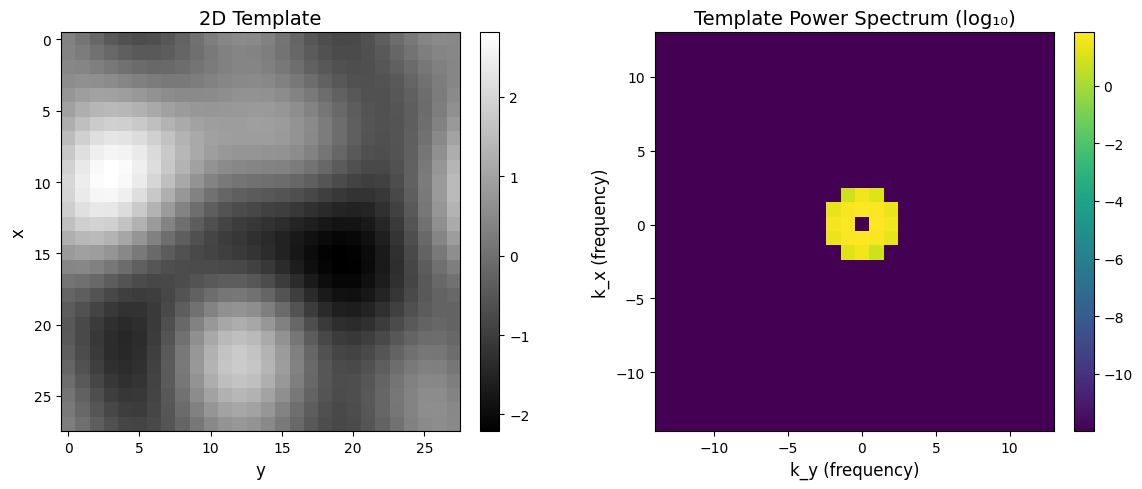

In [8]:
# Reset seeds immediately before creating the template and dataset.
rng = set_reproducibility(GLOBAL_SEED)

# 2D dimensions
p1, p2 = 28, 28  # Can be different, but start with square
p_flat = p1 * p2

# Generate 2D template deterministically.
template_2d = generate_template_unique_freqs(
    p1, p2, n_freqs=10, seed=GLOBAL_SEED
)

# Mean center template
template_2d = template_2d - np.mean(template_2d)

# Visualize template and its spectrum
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_2d_signal(axes[0], template_2d, title="2D Template", cmap="grey")
power_2d, fx, fy = get_power_2d(template_2d)
plot_2d_power_spectrum(axes[1], power_2d, fx, fy, title="Template Power Spectrum")
plt.tight_layout()
plt.show()


In [9]:
# Build sequence data
# Keep CUDA enabled for speed; deterministic settings above make reruns reproducible on the same hardware.
# For the strictest cross-machine bitwise reproducibility, set USE_CUDA_IF_AVAILABLE = False.
USE_CUDA_IF_AVAILABLE = True
device = "cuda" if (USE_CUDA_IF_AVAILABLE and torch.cuda.is_available()) else "cpu"

# Reset NumPy before sampled dataset generation.
np.random.seed(GLOBAL_SEED)
k = 3  # sequence length
mode = "sampled"
num_samples = 100000

X_seq_2d, Y_seq_2d, sequence_xy = ModularAdditionSequenceDataset2D(
    p1, p2, template_2d, k, mode=mode, num_samples=num_samples
)

# Convert to torch tensors
X_seq_2d_t = torch.tensor(X_seq_2d, dtype=torch.float32, device=device)
Y_seq_2d_t = torch.tensor(Y_seq_2d, dtype=torch.float32, device=device)

print(f"Dataset shapes:")
print(f"  X: {X_seq_2d_t.shape}  (N, k, p1*p2)")
print(f"  Y: {Y_seq_2d_t.shape}  (N, p1*p2)")
print(f"  Flattened dimension: {p_flat}")

Dataset shapes:
  X: torch.Size([100000, 3, 784])  (N, k, p1*p2)
  Y: torch.Size([100000, 784])  (N, p1*p2)
  Flattened dimension: 784


### Train 2D model

In [10]:
# Reset all random state immediately before shuffling and model initialization.
rng = set_reproducibility(GLOBAL_SEED)

batch_size = 1000
seq_dataset_2d = TensorDataset(X_seq_2d_t, Y_seq_2d_t)
seq_loader_2d = DataLoader(
    seq_dataset_2d,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    generator=rng,
    num_workers=0,
)

# Model: p is the flattened group representation dimension, p1 * p2 = |G|.
hidden_dim_2d = 100
rnn_2d = QuadraticRNN(p=p_flat, d=hidden_dim_2d, init_scale=1e-5).to(device)

criterion = nn.MSELoss()

weight_decay = 0  # relevant for W_mix plot
learning_rate = 0.0001

optimizer = optim.Adam(
    rnn_2d.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=weight_decay
)

epochs = 150

loss_hist_2d, acc_hist_2d, param_hist_2d = train_seq(
    rnn_2d,
    seq_loader_2d,
    criterion,
    optimizer,
    epochs=epochs,
    verbose_interval=5,
    grad_clip=0.1,
)


[RNN] Epoch 5/150 | loss 1.000000 | acc 0.13%
[RNN] Epoch 10/150 | loss 1.000000 | acc 0.15%
[RNN] Epoch 15/150 | loss 0.891734 | acc 0.00%
[RNN] Epoch 20/150 | loss 0.360929 | acc 0.00%
[RNN] Epoch 25/150 | loss 0.182325 | acc 0.00%
[RNN] Epoch 30/150 | loss 0.173463 | acc 0.00%
[RNN] Epoch 35/150 | loss 0.109395 | acc 0.00%
[RNN] Epoch 40/150 | loss 0.109333 | acc 0.00%
[RNN] Epoch 45/150 | loss 0.109191 | acc 0.00%
[RNN] Epoch 50/150 | loss 0.109130 | acc 0.00%
[RNN] Epoch 55/150 | loss 0.108968 | acc 0.00%
[RNN] Epoch 60/150 | loss 0.102539 | acc 0.00%
[RNN] Epoch 65/150 | loss 0.054733 | acc 0.00%
[RNN] Epoch 70/150 | loss 0.054672 | acc 0.00%
[RNN] Epoch 75/150 | loss 0.054597 | acc 0.00%
[RNN] Epoch 80/150 | loss 0.054536 | acc 0.00%
[RNN] Epoch 85/150 | loss 0.054465 | acc 0.00%
[RNN] Epoch 90/150 | loss 0.054414 | acc 0.00%
[RNN] Epoch 95/150 | loss 0.054296 | acc 0.00%
[RNN] Epoch 100/150 | loss 0.018400 | acc 0.18%
[RNN] Epoch 105/150 | loss 0.018253 | acc 0.03%
[RNN] Epoch 

## Loss Plot

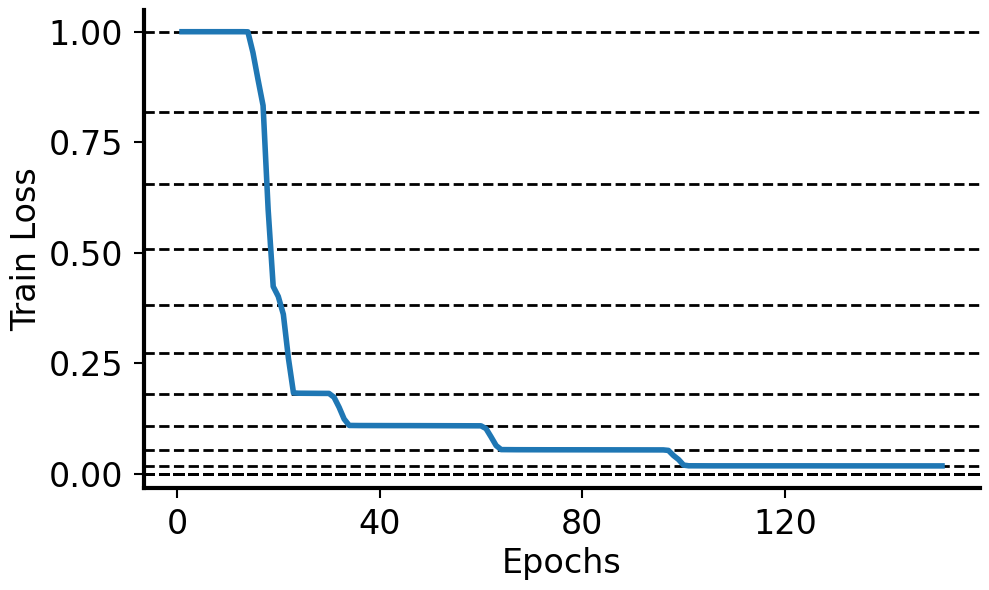

In [11]:
# --- Plot RNN training loss only ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# x-axis = epochs 1..T
x = np.arange(1, len(loss_hist_2d) + 1)
ax.plot(x, loss_hist_2d, lw=4)

# === Compute power spectrum of template ===
x_freq, y_freq, power = get_power_2d_adele(template_2d)
power = power.flatten()
valid = power > 1e-20
power = power[valid]
sorted_idx = np.argsort(power)[::-1]  # np.argsort with [::-1] gives descending order
power = power[sorted_idx]
# print("Power in x: {}".format(power))

# Plot theoretical lines
alpha_values = [np.sum(power[k:]) for k in range(len(power))]
coef = 1 / (p1 * p2)
for k, alpha in enumerate(alpha_values):
    ax.axhline(y=coef*alpha, color='black', linestyle='--', linewidth=2, zorder=-2)


# # Steps
# steps = [1, 20, 50, len(param_hist) - 1]  # make sure these are < len(rnn_param_hist)
# for step in steps:
#     ax.axvline(step, c="k")

# plot in log scale
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_ylim(3.5e-2, 1.3e-1)

ax.set_xlabel("Epochs", fontsize=24)
ax.set_ylabel("Train Loss", fontsize=24)

style_axes(ax)

plt.grid(False)
plt.tight_layout()
#plt.savefig("rnn-loss.pdf", bbox_inches="tight")
plt.show()

## Prediction Power Spectrum Over Time


Computing prediction power: 100%|████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 269.29it/s]


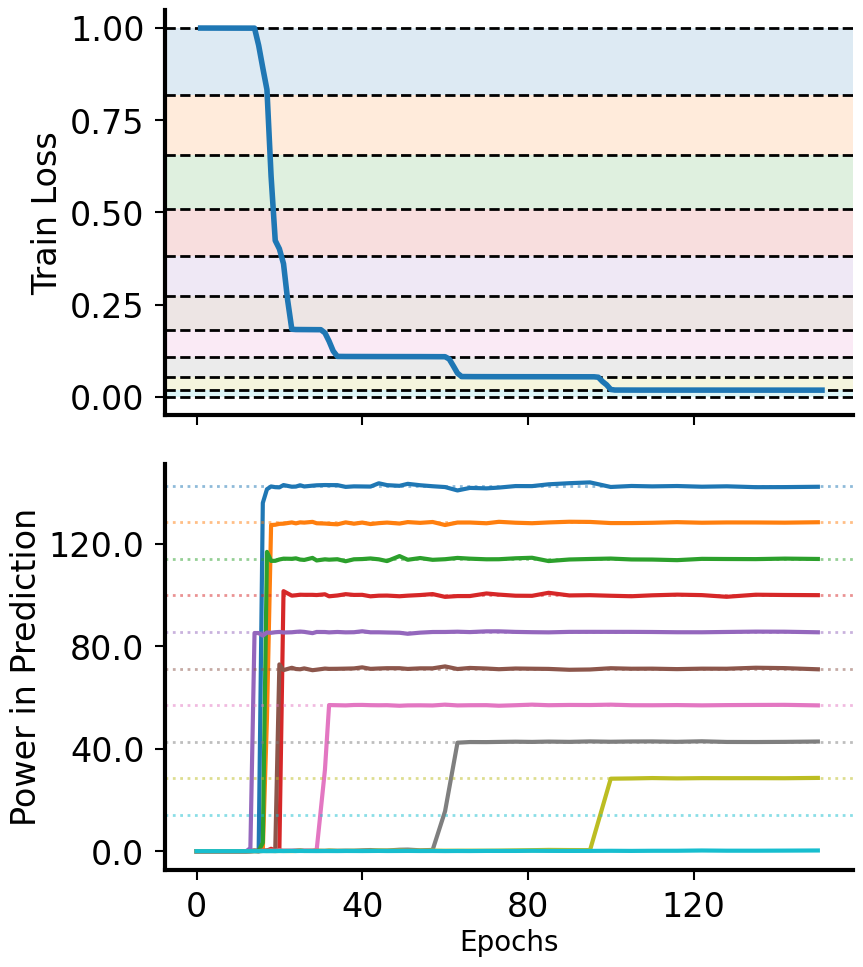

In [12]:
# Track the power in the prediction at the dominant template frequencies.

# Pick top-K frequencies from the template's 2D power spectrum.
num_freqs_to_track = 10
tracked_freqs = topk_template_freqs(template_2d, K=num_freqs_to_track)

# Use the same weighted rFFT convention for targets and predictions.
_, _, template_power_2d = get_power_2d_adele(template_2d)
target_powers = {(kx, ky): template_power_2d[kx, ky] for (kx, ky) in tracked_freqs}

# Choose deterministic analysis steps.
num_points = 100
num_power_samples = 100
T = len(param_hist_2d)
steps_2d_analysis = np.unique(
    np.logspace(0, np.log10(max(T - 1, 1)), num_points, dtype=int)
)
steps_2d_analysis = steps_2d_analysis[steps_2d_analysis < T]
steps_2d_analysis = np.unique(np.insert(steps_2d_analysis, 0, 0))

# Use the first examples in the fixed dataset, rather than a random example.
X_power = X_seq_2d_t[:num_power_samples].to(device)

powers_over_time_2d = {freq: [] for freq in tracked_freqs}

with torch.no_grad():
    for step in tqdm(steps_2d_analysis, desc="Computing prediction power"):
        rnn_2d.load_state_dict(param_hist_2d[step], strict=True)
        rnn_2d.eval()

        outputs_flat = rnn_2d(X_power).detach().cpu().numpy()

        powers_batch = []
        for i in range(outputs_flat.shape[0]):
            out_2d = outputs_flat[i].reshape(p1, p2)
            _, _, power_i = get_power_2d_adele(out_2d)
            powers_batch.append(power_i)

        avg_power = np.mean(powers_batch, axis=0)

        for freq in tracked_freqs:
            kx, ky = freq
            powers_over_time_2d[freq].append(avg_power[kx, ky])

for freq in tracked_freqs:
    powers_over_time_2d[freq] = np.asarray(powers_over_time_2d[freq])


# Plot training loss and prediction power using matched frequency colors.
colors_2d = plt.cm.tab10(np.linspace(0, 1, len(tracked_freqs)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
fig.subplots_adjust(left=0.12, right=0.98, top=0.96, bottom=0.10, hspace=0.12)

# Top: training loss with theoretical power levels.
x = np.arange(1, len(loss_hist_2d) + 1)
ax1.plot(x, loss_hist_2d, lw=4, zorder=5)

_, _, template_power = get_power_2d_adele(template_2d)
power_flat = np.sort(template_power.flatten()[template_power.flatten() > 1e-20])[::-1]

alpha_values = np.array([np.sum(power_flat[k:]) for k in range(len(power_flat))])
y_levels = alpha_values / (p1 * p2)

n_bands = min(len(tracked_freqs), len(y_levels) - 1)
for i in range(n_bands):
    ax1.axhspan(
        y_levels[i + 1],
        y_levels[i],
        facecolor=colors_2d[i],
        alpha=0.15,
        zorder=-3,
    )

for y in y_levels[:n_bands + 1]:
    ax1.axhline(y=y, color="black", linestyle="--", linewidth=2, zorder=-2)

ax1.set_ylabel("Train Loss", fontsize=24)
style_axes(ax1)
ax1.grid(False)
ax1.tick_params(labelbottom=False)

# Bottom: tracked prediction power over time.
for i, freq in enumerate(tracked_freqs):
    kx, ky = freq
    ax2.plot(
        steps_2d_analysis,
        powers_over_time_2d[freq],
        color=colors_2d[i],
        lw=3,
    )
    ax2.axhline(
        target_powers[freq],
        color=colors_2d[i],
        linestyle="dotted",
        linewidth=2,
        alpha=0.5,
    )

ax2.set_xlabel("Epochs", fontsize=20)
ax2.set_ylabel("Power in Prediction", fontsize=24)
ax2.grid(True, alpha=0.3)
style_axes(ax2)
ax2.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

plt.savefig("prediction-power-over-time.pdf", bbox_inches="tight")
plt.show()


## Shared frequency labels for weight plots


In [13]:
# Reuse tracked_freqs from the prediction-power analysis when available.
# If this section is run independently, compute the same deterministic list here.
try:
    tracked_freqs
except NameError:
    num_freqs_to_track = 10
    tracked_freqs = topk_template_freqs(template_2d, K=num_freqs_to_track)


## W_out Plot

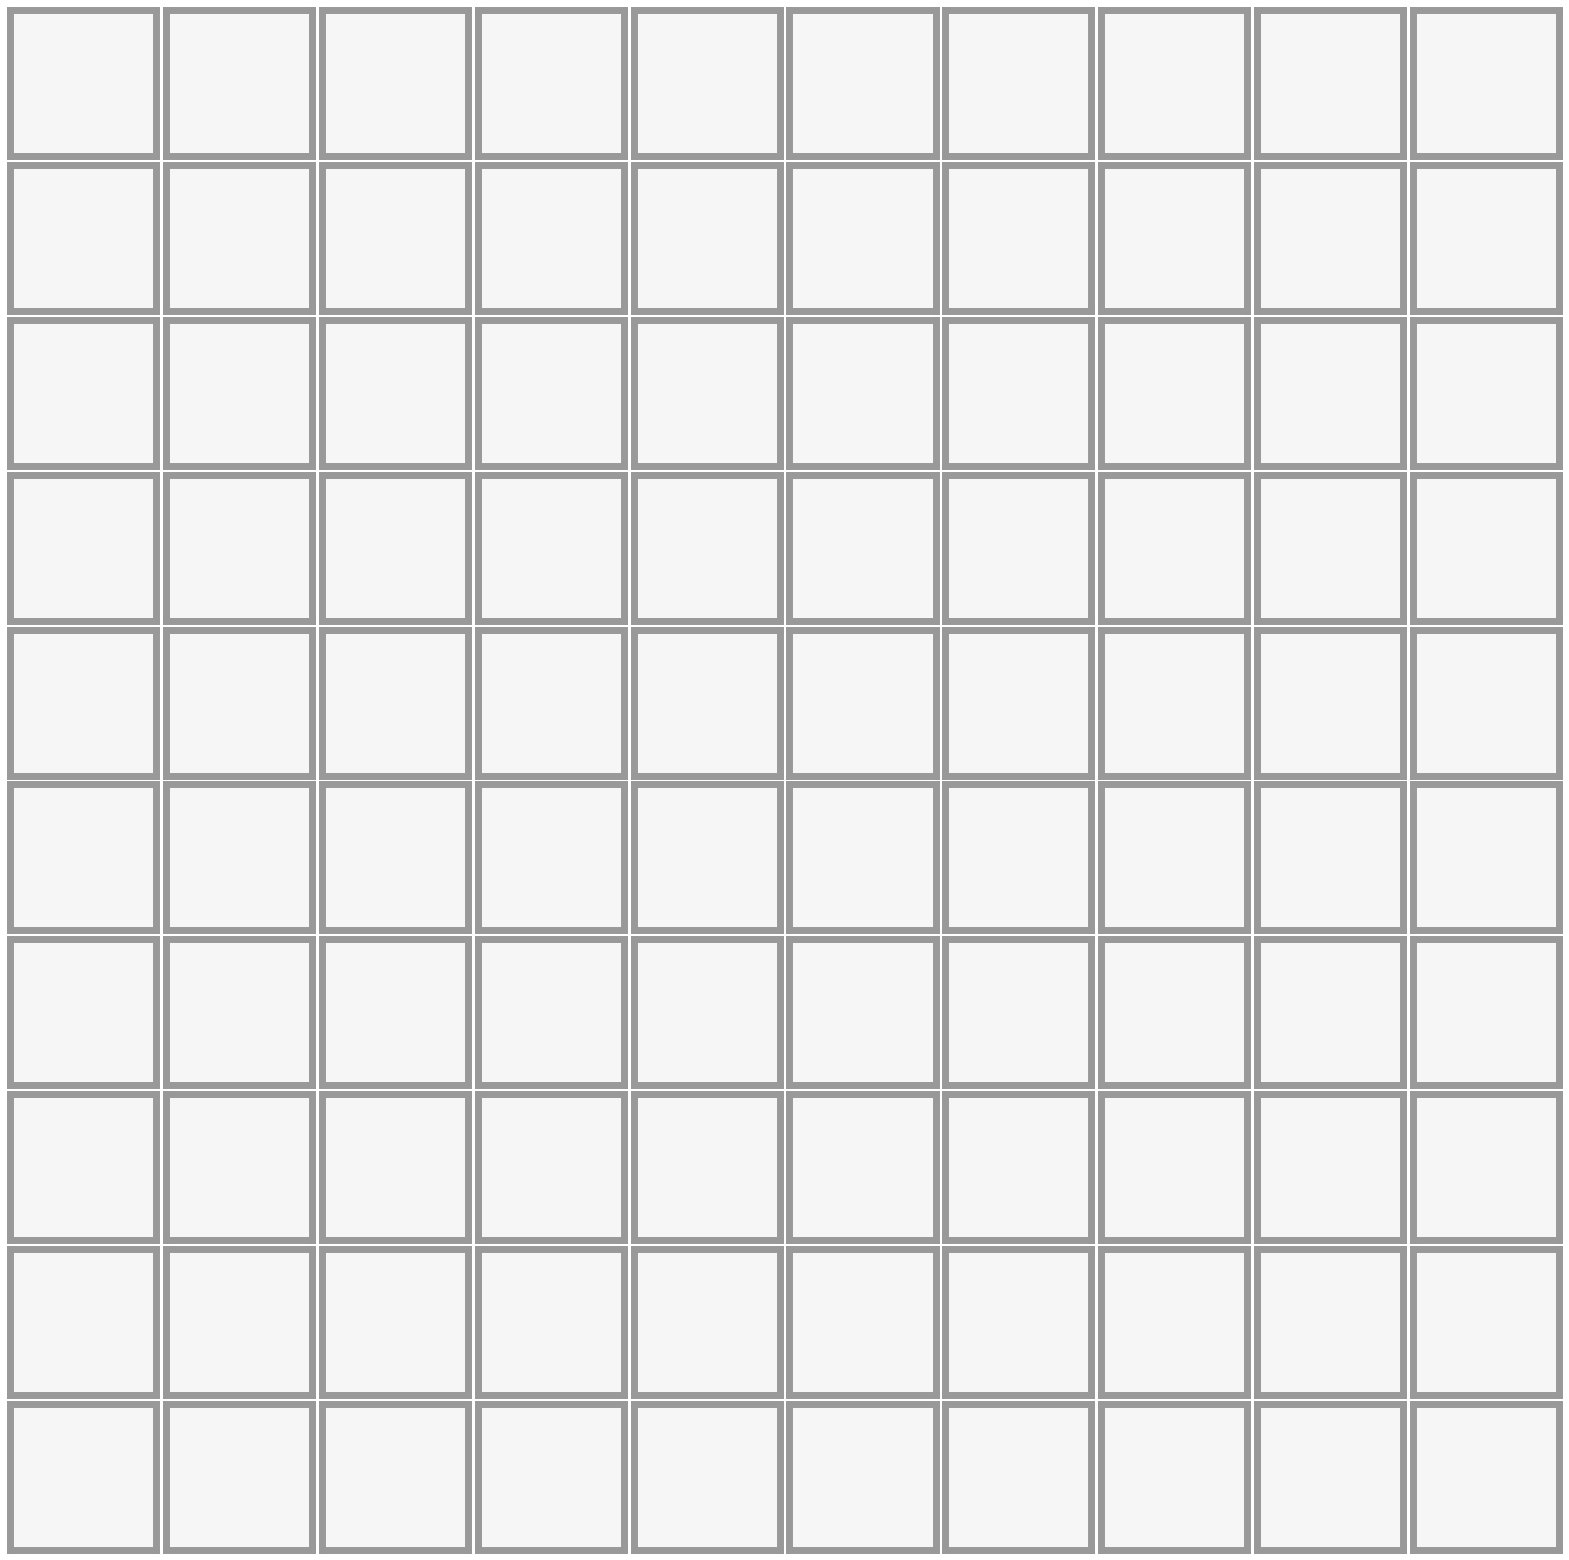

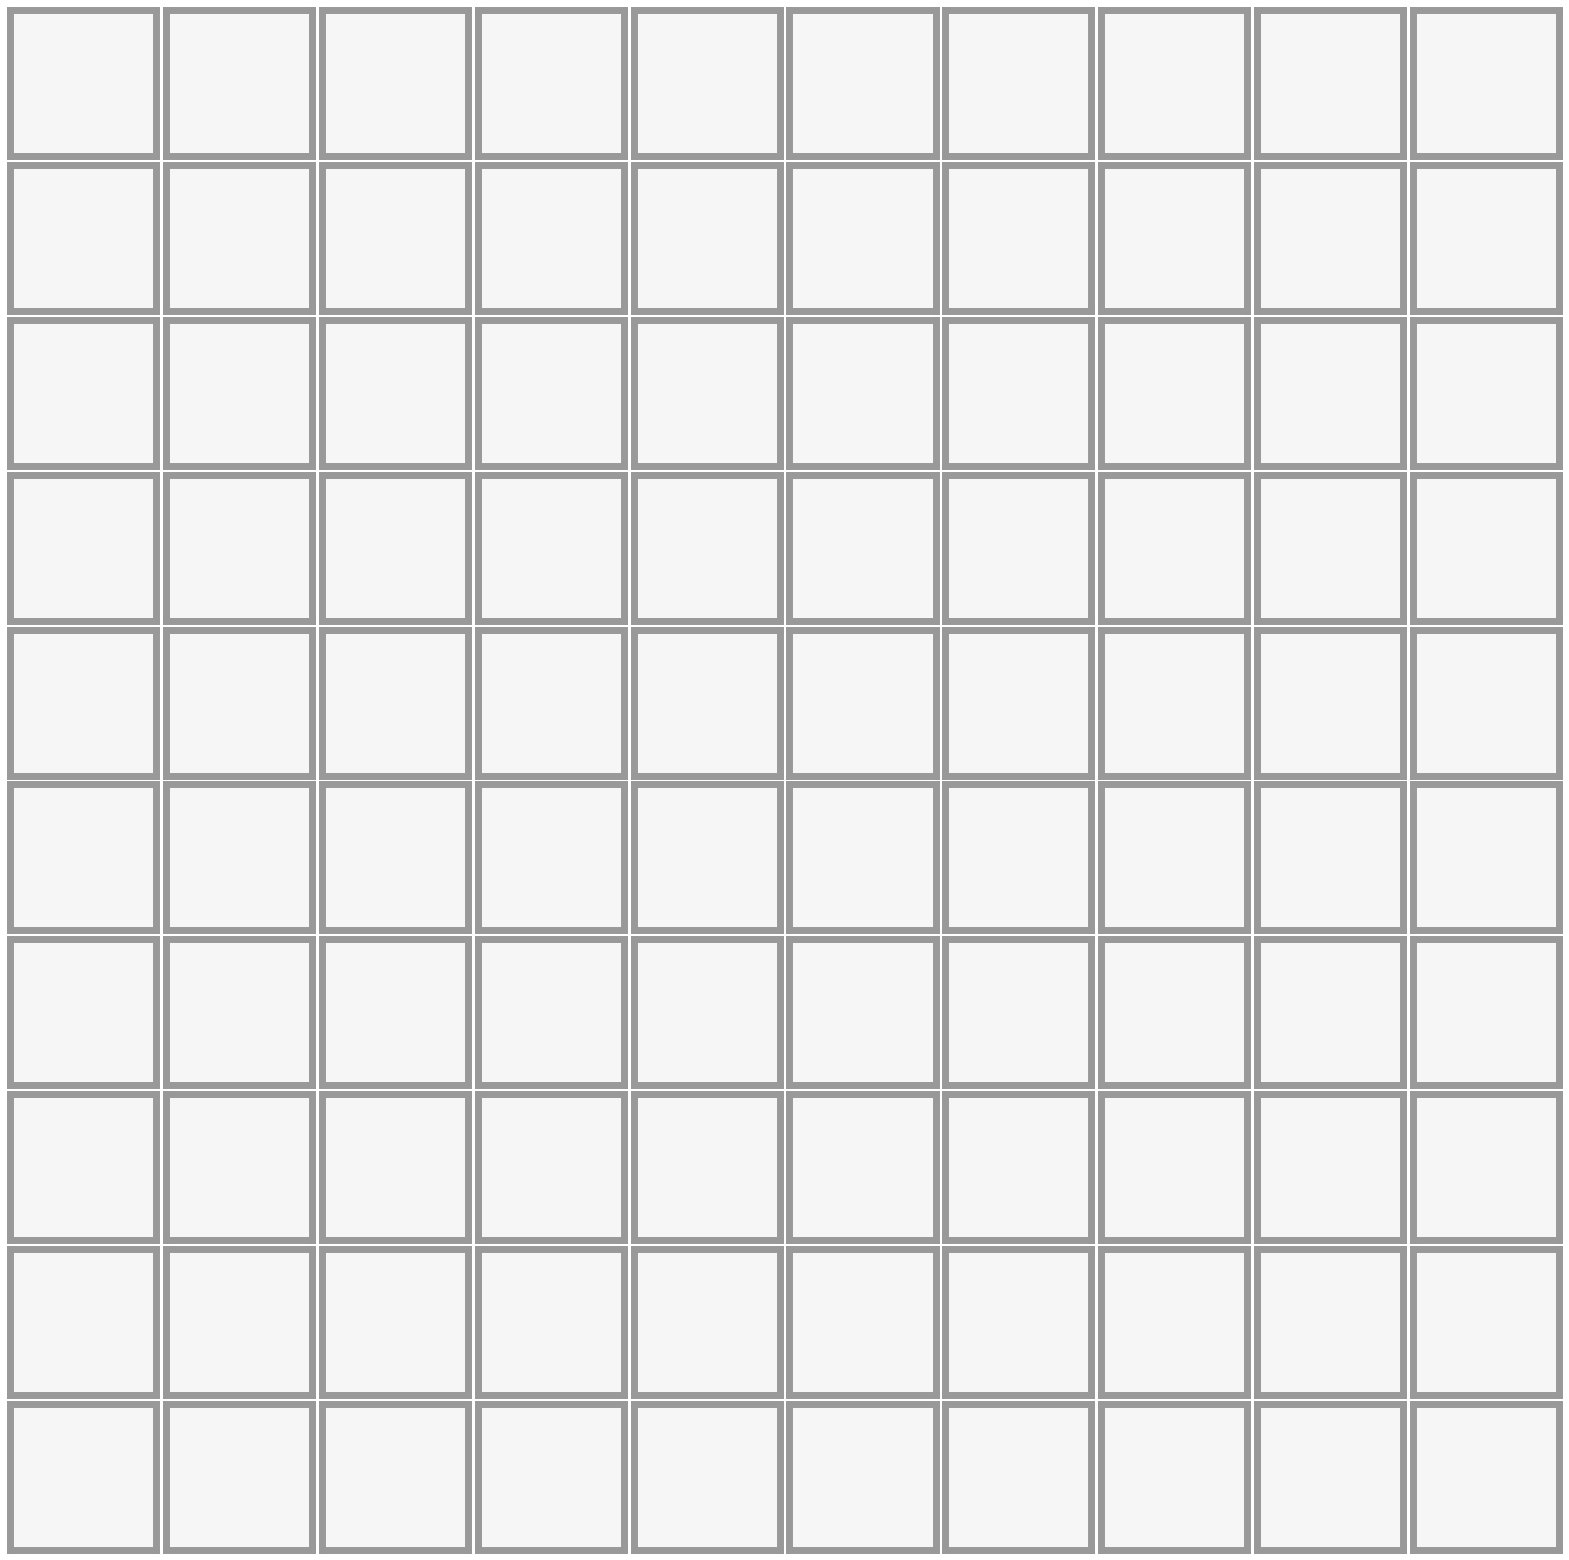

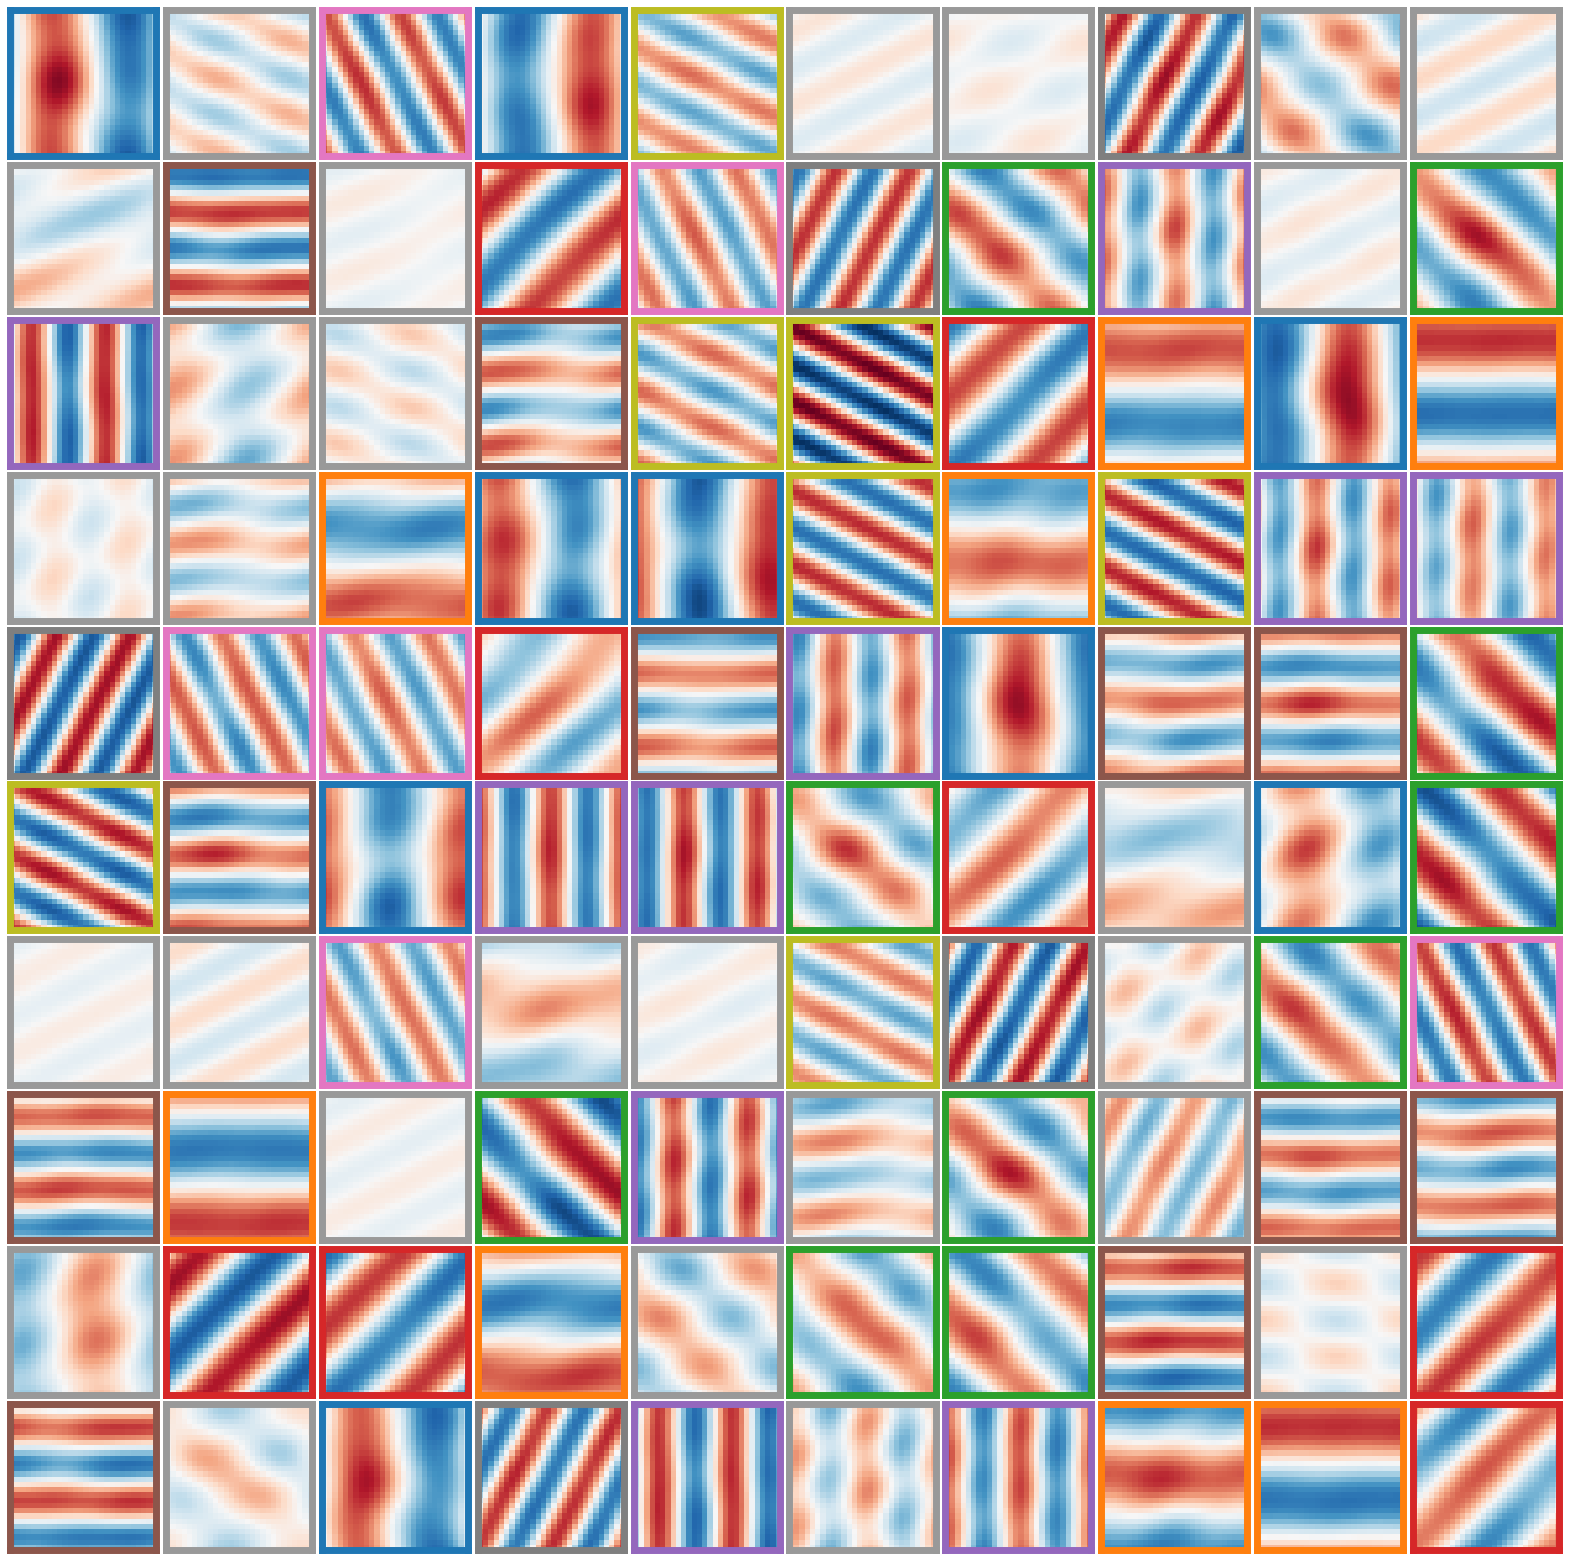

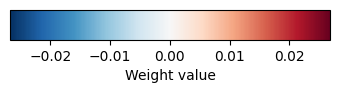

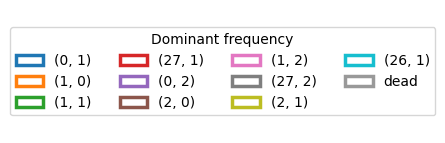

In [14]:
# ========= Inputs you already have =========
# param_hist_2d : list of state-dicts with key "W_out"
# p1, p2        : reshape dims (p1 * p2 == D)

# ========= Config =========
steps_2d = [5, 10, len(param_hist_2d) - 1]
dead_thresh_l2 = 0.25          # absolute L2-norm threshold for "dead" neurons
heat_cmap = "RdBu_r"          # colormap for heatmaps (weight values)
border_lw = 5.0                # border width for neuron tiles
title_fs = 18                  # suptitle font size

# Colors for categories
palette = plt.cm.tab10(np.linspace(0, 1, len(tracked_freqs)))
dead_color = (0.6, 0.6, 0.6, 1.0)

# ========= Tiny helpers =========
def squareish_grid(n):
    c = int(np.ceil(np.sqrt(n)))
    r = int(np.ceil(n / c))
    return r, c

def tracked_power_from_fft2(power2d, kx, ky, p1, p2):
    """Sum power at (kx,ky) and its real-signal mirror (-kx,-ky)."""
    i0, j0 = kx % p1, ky % p2
    i1, j1 = (-kx) % p1, (-ky) % p2
    if (i0, j0) == (i1, j1):
        return power2d[i0, j0]
    return power2d[i0, j0] + power2d[i1, j1]

# ========= Prep: sizes and global color limits =========
W0 = param_hist_2d[steps_2d[0]]["W_out"].detach().cpu().numpy().T  # (H, D)
H, D = W0.shape
assert p1 * p2 == D, f"p1*p2 ({p1*p2}) must equal D ({D})."

vmin, vmax = np.inf, -np.inf
for step in steps_2d:
    W = param_hist_2d[step]["W_out"].detach().cpu().numpy().T
    vmin = min(vmin, W.min())
    vmax = max(vmax, W.max())

# ========= One figure per time step =========
R_ner, C_ner = squareish_grid(H)
tile_w, tile_h = 2, 2  # inches per neuron tile
figsize = (C_ner * tile_w, R_ner * tile_h)

for step in steps_2d:
    W = param_hist_2d[step]["W_out"].detach().cpu().numpy().T  # (H, D)

    # Dominant tracked frequency + dead mask
    dom_idx = np.empty(H, dtype=int)
    l2 = np.linalg.norm(W, axis=1)
    dead_mask = l2 < dead_thresh_l2

    for j in range(H):
        m = W[j].reshape(p1, p2)
        F = np.fft.fft2(m)
        P = (F.conj() * F).real
        tp = [tracked_power_from_fft2(P, kx, ky, p1, p2) for (kx, ky) in tracked_freqs]
        dom_idx[j] = int(np.argmax(tp))

    edge_colors = palette[dom_idx]
    edge_colors[dead_mask] = dead_color

    # Build figure for this time step
    fig = plt.figure(figsize=figsize)
    # fig.suptitle(f"step {step}", fontsize=title_fs, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(R_ner, C_ner, figure=fig, wspace=0.06, hspace=0.06)

    # Plot tiles
    for j in range(R_ner * C_ner):
        ax = fig.add_subplot(gs[j // C_ner, j % C_ner])
        if j < H:
            m = W[j].reshape(p1, p2)
            im = ax.imshow(m, vmin=vmin, vmax=vmax, origin="lower", aspect="equal", cmap=heat_cmap)
            # border highlight
            ec = edge_colors[j]
            for sp in ax.spines.values():
                sp.set_edgecolor(ec)
                sp.set_linewidth(border_lw)
        else:
            ax.axis("off")

        ax.set_xticks([]); ax.set_yticks([])
    plt.savefig(f"step {step}", bbox_inches="tight", dpi=200)
    plt.show()

# ========= Standalone GLOBAL COLORBAR figure =========
fig_cb = plt.figure(figsize=(4, 1.0))  # wide short bar
ax_cb = fig_cb.add_axes([0.1, 0.35, 0.8, 0.3])  # [left, bottom, width, height]
norm = Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap=heat_cmap)
cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation="horizontal")
cbar.set_label("Weight value")
plt.show()

# ========= Standalone LEGEND figure for dominant frequency =========
fig_legend = plt.figure(figsize=(5, 1.6))
ax_leg = fig_legend.add_subplot(111)
ax_leg.axis("off")

# Use patches with COLORED EDGES (to match tile borders)
handles = [
    Patch(facecolor="white", edgecolor=palette[i], linewidth=2.5, label=tracked_freqs[i])
    for i in range(len(tracked_freqs))
]
handles.append(Patch(facecolor="white", edgecolor=dead_color, linewidth=2.5, label="dead"))

leg = ax_leg.legend(handles=handles, ncol=4, frameon=True, loc="center", title="Dominant frequency")
plt.show()

## W_mix Plot

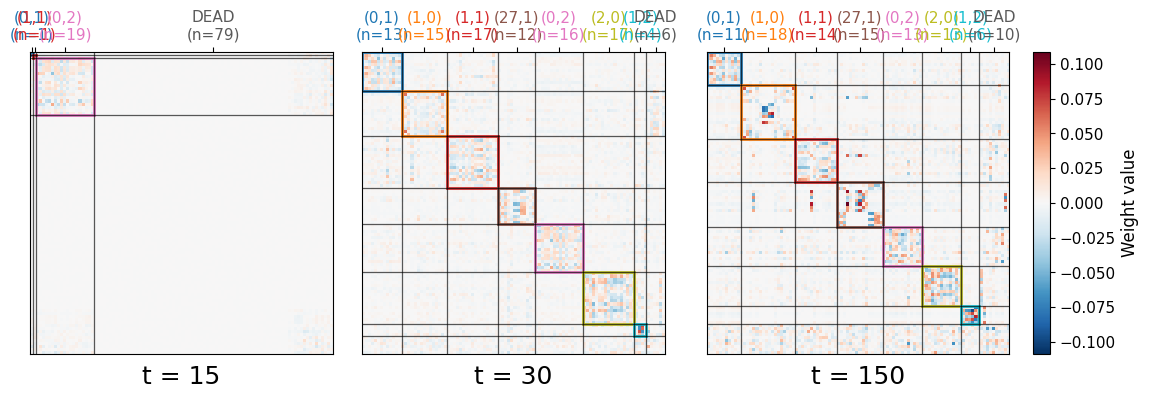

In [15]:
# =========================
# Config
# =========================
within_group_order = "phase"   # 'phase' | 'power' | 'phase_power' | 'none'
outfile = "Wmix_grouped_by_Wo_freq_labeled.pdf"
cmap = "RdBu_r"

TITLE_FONTSIZE   = 18
LABEL_FONTSIZE   = 11
CBAR_LABEL_SIZE  = 12
CBAR_TICK_SIZE   = 11
SEPARATOR_LW     = 0.9
BLOCK_EDGE_LW    = 2.0

dead_l2_thresh   = 0.1
dead_position    = "last"

# how many template freqs to track/label
num_freqs_to_track = 7   # e.g., like your old list length

# You must have template_2d (shape p1 x p2) defined.
p1, p2 = template_2d.shape

# =========================
# Helpers (2D, top-K tracked)
# =========================
def topk_template_freqs(template_2d: np.ndarray, K: int, min_power: float = 1e-20):
    # Use your get_power_2d_adele(template_2d) -> (freqs_u, freqs_v, power)
    freqs_u, freqs_v, power = get_power_2d_adele(template_2d)  # power: (p1, p2//2+1) or similar
    shp = power.shape
    flat = power.ravel()
    mask = flat > min_power
    if not np.any(mask):
        return []
    top_idx = np.flatnonzero(mask)[np.argsort(flat[mask])[::-1]][:K]
    kx, ky = np.unravel_index(top_idx, shp)
    return list(zip(kx.tolist(), ky.tolist()))

def tracked_power_from_fft2(power2d, kx, ky, p1, p2):
    i0, j0 = kx % p1, ky % p2
    i1, j1 = (-kx) % p1, (-ky) % p2
    if (i0, j0) == (i1, j1):
        return float(power2d[i0, j0])
    return float(power2d[i0, j0] + power2d[i1, j1])

def analyze_Wo_tracked(sd, tracked_freqs, p1, p2):
    """
    For each neuron row of W_o, find the dominant freq among tracked_freqs.
    Returns:
      dom_idx (index into tracked_freqs), phase (at rep bin), dom_power, l2, D
    """
    Wo = sd["W_out"].detach().cpu().numpy()   # (p, H) with p = p1*p2
    W  = Wo.T                                # (H, p)
    H, D = W.shape
    assert D == p1 * p2

    dom_idx  = np.empty(H, dtype=int)
    dom_pow  = np.empty(H, dtype=float)
    phase    = np.empty(H, dtype=float)
    l2       = np.linalg.norm(W, axis=1)

    for j in range(H):
        m = W[j].reshape(p1, p2)
        F = np.fft.fft2(m)
        P = (F.conj() * F).real
        # power only at tracked bins (with symmetry accounted)
        tp = [tracked_power_from_fft2(P, kx, ky, p1, p2) for (kx, ky) in tracked_freqs]
        jj = int(np.argmax(tp))
        dom_idx[j] = jj
        # phase at representative positive bin
        i0, j0 = tracked_freqs[jj][0] % p1, tracked_freqs[jj][1] % p2
        phase[j] = np.angle(F[i0, j0])
        dom_pow[j] = tp[jj]
    return dom_idx, phase, dom_pow, l2, D

def permutation_from_groups_with_dead(dom_idx, phase, dom_power, l2,
                                      *, within="phase", dead_l2_thresh=1e-1, dead_position="last"):
    dead_mask = (l2 < float(dead_l2_thresh))
    groups = {}
    for i, f in enumerate(dom_idx):
        key = -1 if dead_mask[i] else int(f)  # f is index into tracked_freqs
        groups.setdefault(key, []).append(i)

    freq_keys = sorted([k for k in groups.keys() if k >= 0])
    ordered_keys = (freq_keys + [-1]) if dead_position == "last" else ([-1] + freq_keys)
    group_keys = [k for k in ordered_keys if k in groups]

    perm, boundaries = [], []
    for f in group_keys:
        idxs = groups[f]
        if f == -1:
            idxs = sorted(idxs, key=lambda i: l2[i])
        else:
            if within == "phase" and phase is not None:
                idxs = sorted(idxs, key=lambda i: (phase[i] + 2*np.pi) % (2*np.pi))
            elif within == "power" and dom_power is not None:
                idxs = sorted(idxs, key=lambda i: -dom_power[i])
            elif within == "phase_power" and phase is not None and dom_power is not None:
                idxs = sorted(idxs, key=lambda i: ((phase[i] + 2*np.pi) % (2*np.pi), -dom_power[i]))
        perm.extend(idxs)
        boundaries.append(len(perm))
    return np.array(perm, dtype=int), group_keys, boundaries

def reorder_square(M, perm):
    return M[perm][:, perm]

# labels & colors for the tracked list
tracked_freqs = topk_template_freqs(template_2d, num_freqs_to_track)
tracked_labels = [("DC" if (kx, ky) == (0, 0) else f"({kx},{ky})") for (kx, ky) in tracked_freqs]
def build_freq_colors_tracked(n):
    return plt.cm.tab10(np.linspace(0, 1, n))
freq_colors = build_freq_colors_tracked(len(tracked_freqs))
dead_gray = "0.35"

def add_group_labels_top(ax, group_keys, boundaries, *, show_counts=True, rotation=0, fontsize=LABEL_FONTSIZE):
    starts = [0] + boundaries[:-1]
    ends   = [b - 1 for b in boundaries]
    centers = [(s + e) / 2.0 for s, e in zip(starts, ends)]
    sizes   = [e - s + 1 for s, e in zip(starts, ends)]

    labels = []
    colors = []
    for kk, nn in zip(group_keys, sizes):
        if kk == -1:
            base = "DEAD"; clr = dead_gray
        else:
            base = tracked_labels[kk]
            clr  = freq_colors[kk]
        labels.append(f"{base}\n(n={nn})" if show_counts else base)
        colors.append(clr)

    ax.set_xticks(centers)
    ax.set_xticklabels(labels, rotation=rotation, fontsize=fontsize, ha="center")
    ax.tick_params(axis='x', bottom=False, top=True, labelbottom=False, labeltop=True, labelsize=fontsize)
    for lbl, clr in zip(ax.get_xticklabels(), colors):
        lbl.set_color(clr)

# =========================
# Prepare steps & snapshots
# =========================
steps = [15, 30, len(param_hist_2d) - 1]
Wh_perm_list = []
group_info_list = []

for s in steps:
    sd = param_hist_2d[s]

    # analyze W_o against tracked 2D freqs
    dom_idx, phase, dom_power, l2, D = analyze_Wo_tracked(sd, tracked_freqs, p1, p2)

    # W_mix fallback to W_h
    if "W_mix" in sd:
        M = sd["W_mix"].detach().cpu().numpy()
    elif "W_h" in sd:
        M = sd["W_h"].detach().cpu().numpy()
    else:
        raise KeyError("Neither 'W_mix' nor 'W_h' found in state dict.")

    perm, group_keys, boundaries = permutation_from_groups_with_dead(
        dom_idx, phase, dom_power, l2,
        within=within_group_order,
        dead_l2_thresh=dead_l2_thresh,
        dead_position=dead_position
    )

    M_perm = reorder_square(M, perm)
    Wh_perm_list.append(M_perm)
    group_info_list.append((group_keys, boundaries))

# Shared symmetric color limits
vmax = max(np.max(np.abs(M)) for M in Wh_perm_list)
vmin = -vmax if vmax > 0 else 0.0

# =========================
# Plot
# =========================
n = len(steps)
fig, axes = plt.subplots(1, n, figsize=(3.8*n, 3.8), constrained_layout=True)
try:
    fig.set_constrained_layout_pads(w_pad=0.003, h_pad=0.003, wspace=0.003, hspace=0.003)
except Exception:
    pass
if n == 1:
    axes = [axes]

im = None
for j, (s, M_perm) in enumerate(zip(steps, Wh_perm_list)):
    ax = axes[j]
    im = ax.imshow(M_perm, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")

    ax.set_yticks([])
    ax.tick_params(axis='x', bottom=False)

    group_keys, boundaries = group_info_list[j]
    for b in boundaries[:-1]:
        ax.axhline(b - 0.5, color="k", lw=SEPARATOR_LW, alpha=0.65)
        ax.axvline(b - 0.5, color="k", lw=SEPARATOR_LW, alpha=0.65)

    starts = [0] + boundaries[:-1]
    ends   = [b - 1 for b in boundaries]
    for kk, s0, e0 in zip(group_keys, starts, ends):
        if kk == -1:  # skip DEAD box color
            continue
        size = e0 - s0 + 1
        rect = Rectangle((s0 - 0.5, s0 - 0.5), width=size, height=size,
                         fill=False, linewidth=BLOCK_EDGE_LW,
                         edgecolor=freq_colors[kk], alpha=0.95, joinstyle='miter')
        ax.add_patch(rect)

    add_group_labels_top(ax, group_keys, boundaries, show_counts=True, rotation=0, fontsize=LABEL_FONTSIZE)
    ax.set_xlabel(f"t = {s}", fontsize=TITLE_FONTSIZE, labelpad=8)

# shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=1.0, pad=0.012, aspect=18)
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
cbar.set_label("Weight value", fontsize=CBAR_LABEL_SIZE)

plt.savefig(outfile, bbox_inches="tight", dpi=200)
plt.show()

In [16]:
# =========================
# Save tight heatmaps (keep separators + rectangles; no labels/legend)
# =========================
import os
from matplotlib.patches import Rectangle

base, ext = os.path.splitext(outfile)
if not ext:
    ext = ".png"  # change to ".pdf" if preferred

# Shared symmetric color limits across steps
vmax = max(np.max(np.abs(M)) for M in Wh_perm_list)
vmin = -vmax if vmax > 0 else 0.0

for j, (s, M_perm) in enumerate(zip(steps, Wh_perm_list)):
    # Full-bleed figure (no margins)
    fig = plt.figure(figsize=(3.2, 3.2), dpi=200)
    ax = plt.Axes(fig, [0, 0, 1, 1])  # left, bottom, width, height (normalized)
    fig.add_axes(ax)
    ax.set_axis_off()  # no ticks/labels/frame

    # Heatmap
    ax.imshow(M_perm, cmap=cmap, vmin=vmin, vmax=vmax,
              aspect="equal", interpolation="nearest")

    # Group separators + rectangles
    group_keys, boundaries = group_info_list[j]

    # Thin separator lines between groups
    for b in boundaries[:-1]:
        ax.axhline(b - 0.5, color="k", lw=SEPARATOR_LW, alpha=0.65)
        ax.axvline(b - 0.5, color="k", lw=SEPARATOR_LW, alpha=0.65)

    # Colored block outlines for each non-DEAD group
    starts = [0] + boundaries[:-1]
    ends   = [b - 1 for b in boundaries]
    for kk, s0, e0 in zip(group_keys, starts, ends):
        if kk == -1:
            continue  # skip DEAD group outline
        size = e0 - s0 + 1
        rect = Rectangle((s0 - 0.5, s0 - 0.5), width=size, height=size,
                         fill=False, linewidth=BLOCK_EDGE_LW,
                         edgecolor=freq_colors[kk], alpha=0.95, joinstyle='miter')
        ax.add_patch(rect)

    # Save ultra-tight (no padding, no legend/colorbar/labels)
    per_step_outfile = f"{base}_t{s:04d}_tight{ext}"
    fig.savefig(per_step_outfile, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

print(f"Saved {len(steps)} files like '{base}_t####_tight{ext}' (tight, no labels/legend).")

Saved 3 files like 'Wmix_grouped_by_Wo_freq_labeled_t####_tight.pdf' (tight, no labels/legend).
